## Fase 1 — Comprensión del Negocio

### Contexto
El precio del dólar es una variable macroeconómica clave que afecta importaciones, exportaciones, deuda pública y el poder adquisitivo de los ciudadanos. Contar con un modelo predictivo permite anticipar variaciones del tipo de cambio a partir de indicadores económicos fundamentales.

### Objetivo de minería de datos
Construir un **modelo de regresión lineal múltiple** que permita predecir el `Precio_Dolar` (variable dependiente/cuantitativa continua) usando como predictores el número de día (`Dia`), la tasa de inflación diaria (`Inflacion`) y la tasa de interés diaria (`Tasa_interes`).

### Criterio de éxito
- **R² ≥ 0.80**: el modelo debe explicar al menos el 80% de la varianza del precio.
- **MSE bajo**: error cuadrático medio pequeño en relación con la escala del precio (~4000–6500 COP/USD).
- Coeficientes interpretables con sentido económico.

---
## Fase 2 — Comprensión de los Datos

In [1]:
# ── Importación de librerías ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Estilo visual uniforme
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


In [2]:
# ── Carga del dataset ─────────────────────────────────────────────────────
df = pd.read_csv('dolar_data.csv')

print('═' * 50)
print('  INFORMACIÓN GENERAL DEL DATASET')
print('═' * 50)
print(f'  Filas    : {df.shape[0]}')
print(f'  Columnas : {df.shape[1]}')
print(f'  Memoria  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print(df.dtypes.to_string())
print()
df.head(10)

══════════════════════════════════════════════════
  INFORMACIÓN GENERAL DEL DATASET
══════════════════════════════════════════════════
  Filas    : 500
  Columnas : 4
  Memoria  : 15.8 KB

Dia               int64
Inflacion       float64
Tasa_interes    float64
Precio_Dolar    float64



,Dia,Inflacion,Tasa_interes,Precio_Dolar
0,1,0.022484,5.463089,4024.833598
1,2,0.019309,5.954708,4000.546337
2,3,0.023238,4.300716,3979.622045
3,4,0.027615,5.281485,3940.361345
4,5,0.018829,4.674679,4016.930225
5,6,0.018829,4.756437,4005.875759
6,7,0.027896,4.703803,4038.300843
7,8,0.023837,4.568005,4030.845979
8,9,0.017653,5.024261,4050.765553
9,10,0.022713,4.584525,3981.935550


In [3]:
# ── Estadísticas descriptivas ─────────────────────────────────────────────
print('═' * 50)
print('  ESTADÍSTICAS DESCRIPTIVAS')
print('═' * 50)
df.describe().round(4)

══════════════════════════════════════════════════
  ESTADÍSTICAS DESCRIPTIVAS
══════════════════════════════════════════════════


,Dia,Inflacion,Tasa_interes,Precio_Dolar
count,500.0000,500.0000,500.0000,500.0000
mean,250.5000,0.0200,5.0159,5211.7719
std,144.4818,0.0049,0.4890,723.8952
min,1.0000,0.0038,3.6516,3940.3613
25%,125.7500,0.0165,4.7024,4604.8850
50%,250.5000,0.0201,5.0143,5218.7911
75%,375.2500,0.0232,5.3256,5825.2353
max,500.0000,0.0393,6.3162,6553.5986


In [4]:
# ── Verificación de calidad de datos ─────────────────────────────────────
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Filas duplicadas:', df.duplicated().sum())
print()

# Rangos y observaciones relevantes
print('─' * 50)
print('Rango Precio_Dolar : {:.2f} – {:.2f}'.format(df['Precio_Dolar'].min(), df['Precio_Dolar'].max()))
print('Rango Inflacion    : {:.5f} – {:.5f}'.format(df['Inflacion'].min(), df['Inflacion'].max()))
print('Rango Tasa_interes : {:.4f} – {:.4f}'.format(df['Tasa_interes'].min(), df['Tasa_interes'].max()))
print('Rango Dia          : {} – {}'.format(int(df['Dia'].min()), int(df['Dia'].max())))

Valores nulos por columna:
Dia             0
Inflacion       0
Tasa_interes    0
Precio_Dolar    0
dtype: int64

Filas duplicadas: 0

──────────────────────────────────────────────────
Rango Precio_Dolar : 3940.36 – 6553.60
Rango Inflacion    : 0.00379 – 0.03926
Rango Tasa_interes : 3.6516 – 6.3162
Rango Dia          : 1 – 500


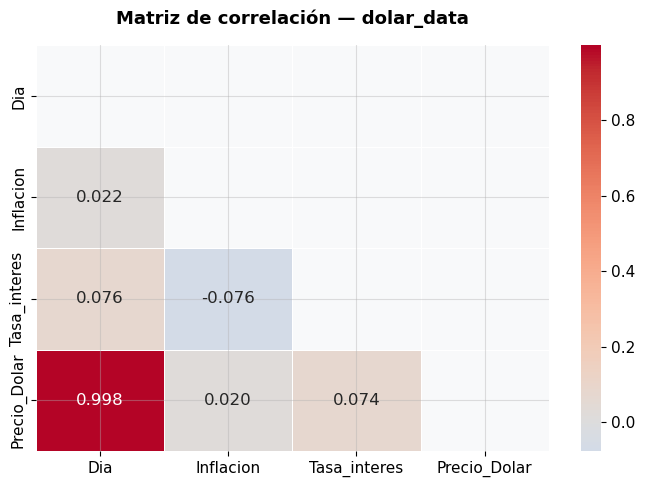


Correlación con Precio_Dolar:
Dia             0.997579
Tasa_interes    0.074299
Inflacion       0.019595
Name: Precio_Dolar, dtype: float64


In [5]:
# ── Matriz de correlación ─────────────────────────────────────────────────
corr = df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.3f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 12}, ax=ax
)
ax.set_title('Matriz de correlación — dolar_data', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelación con Precio_Dolar:')
print(corr['Precio_Dolar'].drop('Precio_Dolar').sort_values(ascending=False))

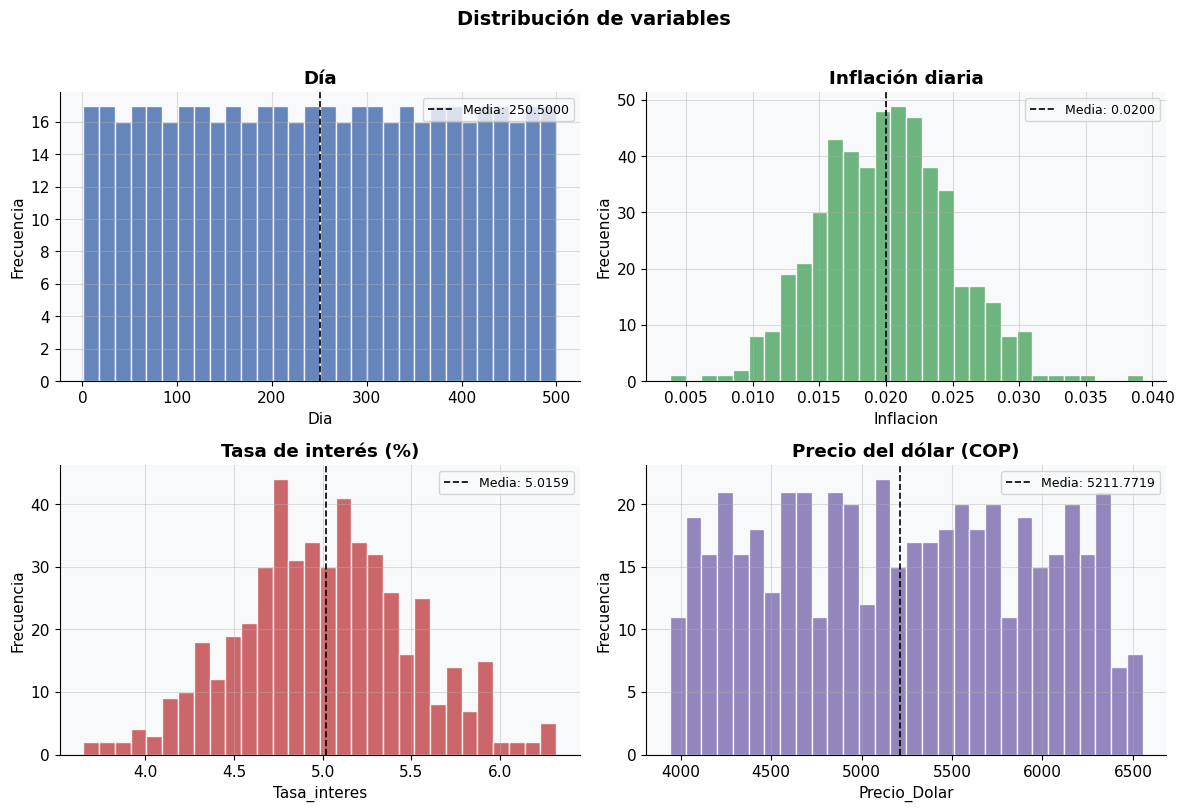

In [6]:
# ── Distribuciones de las variables ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de variables', fontsize=14, fontweight='bold', y=1.01)

cols   = ['Dia', 'Inflacion', 'Tasa_interes', 'Precio_Dolar']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
labels = ['Día', 'Inflación diaria', 'Tasa de interés (%)', 'Precio del dólar (COP)']

for ax, col, color, label in zip(axes.flatten(), cols, colors, labels):
    ax.hist(df[col], bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Media: {df[col].mean():.4f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fase 3 — Preparación de los Datos

In [7]:
# ── Separación de variables ───────────────────────────────────────────────
X = df[['Dia', 'Inflacion', 'Tasa_interes']]
y = df['Precio_Dolar']

print('Variables independientes (X):', X.columns.tolist())
print('Variable dependiente  (y)   :', y.name)
print(f'Forma de X: {X.shape}  |  Forma de y: {y.shape}')

Variables independientes (X): ['Dia', 'Inflacion', 'Tasa_interes']
Variable dependiente  (y)   : Precio_Dolar
Forma de X: (500, 3)  |  Forma de y: (500,)


In [8]:
# ── División train / test (80% / 20%) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Tamaño del conjunto de entrenamiento:', X_train.shape[0], 'registros')
print('Tamaño del conjunto de prueba       :', X_test.shape[0], 'registros')
print(f'Proporción  →  train: {X_train.shape[0]/len(df)*100:.0f}%  |  test: {X_test.shape[0]/len(df)*100:.0f}%')

Tamaño del conjunto de entrenamiento: 400 registros
Tamaño del conjunto de prueba       : 100 registros
Proporción  →  train: 80%  |  test: 20%


In [9]:
# ── Verificar que la distribución se conserva en ambos conjuntos ──────────
print('Media Precio_Dolar — entrenamiento: {:.2f}'.format(y_train.mean()))
print('Media Precio_Dolar — prueba       : {:.2f}'.format(y_test.mean()))
print('Media Precio_Dolar — total        : {:.2f}'.format(y.mean()))
print('\nLa distribución de la variable objetivo es consistente en ambos conjuntos ✓')

Media Precio_Dolar — entrenamiento: 5202.70
Media Precio_Dolar — prueba       : 5248.07
Media Precio_Dolar — total        : 5211.77

La distribución de la variable objetivo es consistente en ambos conjuntos ✓


---
## Fase 4 — Modelado: Regresión Lineal Múltiple

In [10]:
# ── Entrenamiento del modelo ──────────────────────────────────────────────
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Modelo entrenado correctamente ✓')
print()
print('═' * 55)
print('  ECUACIÓN DEL MODELO')
print('═' * 55)
print(f'  Intercepto (β₀)    : {modelo.intercept_:.4f}')
print(f'  β₁ (Dia)           : {modelo.coef_[0]:.4f}')
print(f'  β₂ (Inflacion)     : {modelo.coef_[1]:.4f}')
print(f'  β₃ (Tasa_interes)  : {modelo.coef_[2]:.4f}')
print('─' * 55)
print()
print('Precio_Dolar =')
print(f'  {modelo.intercept_:.2f}')
print(f'  + {modelo.coef_[0]:.4f} × Dia')
print(f'  + {modelo.coef_[1]:.2f} × Inflacion')
print(f'  + {modelo.coef_[2]:.4f} × Tasa_interes')

Modelo entrenado correctamente ✓

═══════════════════════════════════════════════════════
  ECUACIÓN DEL MODELO
═══════════════════════════════════════════════════════
  Intercepto (β₀)    : 3985.7833
  β₁ (Dia)           : 4.9843
  β₂ (Inflacion)     : -870.7317
  β₃ (Tasa_interes)  : -1.3774
───────────────────────────────────────────────────────

Precio_Dolar =
  3985.78
  + 4.9843 × Dia
  + -870.73 × Inflacion
  + -1.3774 × Tasa_interes


In [11]:
# ── Interpretación de los coeficientes ───────────────────────────────────
interpretaciones = {
    'Dia': (
        modelo.coef_[0],
        'Por cada día adicional que pasa, el precio del dólar '
        f'aumenta {abs(modelo.coef_[0]):.2f} COP (tendencia de largo plazo).'
    ),
    'Inflacion': (
        modelo.coef_[1],
        f'Un incremento de 0.001 en la inflación diaria '
        f'cambia el precio en {modelo.coef_[1]*0.001:.2f} COP.'
    ),
    'Tasa_interes': (
        modelo.coef_[2],
        f'Un punto porcentual adicional en la tasa de interés '
        f'cambia el precio en {modelo.coef_[2]:.2f} COP.'
    )
}

print('═' * 65)
print('  INTERPRETACIÓN DE COEFICIENTES')
print('═' * 65)
for var, (coef, interp) in interpretaciones.items():
    signo = '↑ aumenta' if coef > 0 else '↓ disminuye'
    print(f'\n  {var} (β = {coef:.4f})  →  {signo} el precio')
    print(f'  {interp}')

═════════════════════════════════════════════════════════════════
  INTERPRETACIÓN DE COEFICIENTES
═════════════════════════════════════════════════════════════════

  Dia (β = 4.9843)  →  ↑ aumenta el precio
  Por cada día adicional que pasa, el precio del dólar aumenta 4.98 COP (tendencia de largo plazo).

  Inflacion (β = -870.7317)  →  ↓ disminuye el precio
  Un incremento de 0.001 en la inflación diaria cambia el precio en -0.87 COP.

  Tasa_interes (β = -1.3774)  →  ↓ disminuye el precio
  Un punto porcentual adicional en la tasa de interés cambia el precio en -1.38 COP.


---
## Fase 5 — Evaluación del Modelo

In [12]:
# ── Predicciones y métricas ───────────────────────────────────────────────
y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

mse_train  = mean_squared_error(y_train, y_pred_train)
mse_test   = mean_squared_error(y_test,  y_pred_test)
rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
mae_test   = np.mean(np.abs(y_test - y_pred_test))

print('═' * 55)
print('  MÉTRICAS DE DESEMPEÑO')
print('═' * 55)
print(f'  {'Métrica':<22} {'Entrenamiento':>15} {'Prueba':>12}')
print('─' * 55)
print(f'  {'MSE':<22} {mse_train:>15,.2f} {mse_test:>12,.2f}')
print(f'  {'RMSE (COP)':<22} {rmse_train:>15,.2f} {rmse_test:>12,.2f}')
print(f'  {'R²':<22} {r2_train:>15.4f} {r2_test:>12.4f}')
print(f'  {'MAE (COP)':<22} {'—':>15} {mae_test:>12,.2f}')
print('─' * 55)
print()
print(f'  → El modelo explica el {r2_test*100:.1f}% de la varianza del Precio_Dolar')
print(f'  → El error promedio de predicción es ±{rmse_test:.2f} COP')

═══════════════════════════════════════════════════════
  MÉTRICAS DE DESEMPEÑO
═══════════════════════════════════════════════════════
  Métrica                  Entrenamiento       Prueba
───────────────────────────────────────────────────────
  MSE                           2,580.46     2,376.97
  RMSE (COP)                       50.80        48.75
  R²                              0.9948       0.9963
  MAE (COP)                            —        37.01
───────────────────────────────────────────────────────

  → El modelo explica el 99.6% de la varianza del Precio_Dolar
  → El error promedio de predicción es ±48.75 COP


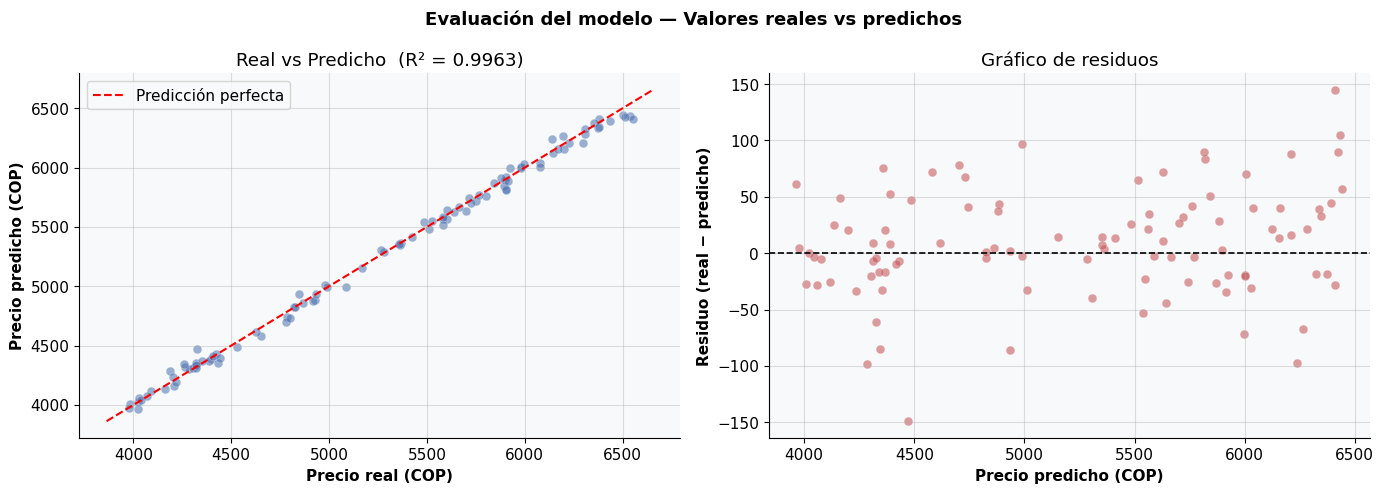

In [13]:
# ── Gráfica 1: Valores reales vs predichos ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación del modelo — Valores reales vs predichos', fontsize=13, fontweight='bold')

# Scatter real vs predicho
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.55, color='#4C72B0', edgecolors='white', linewidths=0.3, s=40)
lim = [min(y_test.min(), y_pred_test.min()) - 100,
       max(y_test.max(), y_pred_test.max()) + 100]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Precio real (COP)', fontweight='bold')
ax.set_ylabel('Precio predicho (COP)', fontweight='bold')
ax.set_title(f'Real vs Predicho  (R² = {r2_test:.4f})')
ax.legend()

# Residuos
residuos = y_test - y_pred_test
ax = axes[1]
ax.scatter(y_pred_test, residuos, alpha=0.55, color='#C44E52', edgecolors='white', linewidths=0.3, s=40)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Precio predicho (COP)', fontweight='bold')
ax.set_ylabel('Residuo (real − predicho)', fontweight='bold')
ax.set_title('Gráfico de residuos')

plt.tight_layout()
plt.savefig('evaluacion_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

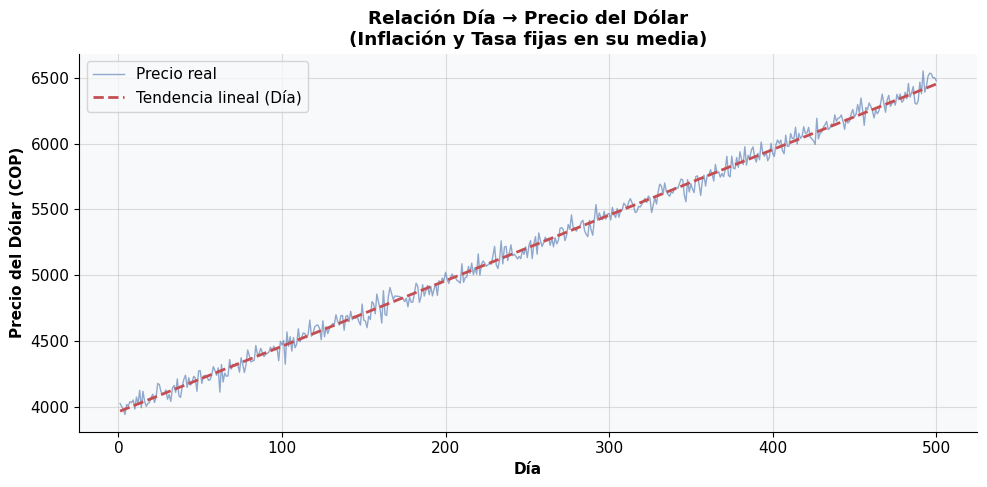

Pendiente (β₁ Dia): 4.9843 COP por día


In [14]:
# ── Gráfica 2: Variable Dia vs Precio_Dolar ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Línea temporal real
ax.plot(df['Dia'], df['Precio_Dolar'], color='#4C72B0', alpha=0.6, linewidth=1, label='Precio real')

# Predicción con solo Dia variable (otras en su media)
X_dia = pd.DataFrame({
    'Dia': df['Dia'],
    'Inflacion': df['Inflacion'].mean(),
    'Tasa_interes': df['Tasa_interes'].mean()
})
y_dia_pred = modelo.predict(X_dia)
ax.plot(df['Dia'], y_dia_pred, color='#C44E52', linewidth=2, linestyle='--', label='Tendencia lineal (Día)')

ax.set_xlabel('Día', fontweight='bold')
ax.set_ylabel('Precio del Dólar (COP)', fontweight='bold')
ax.set_title('Relación Día → Precio del Dólar\n(Inflación y Tasa fijas en su media)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('relacion_dia.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pendiente (β₁ Dia): {modelo.coef_[0]:.4f} COP por día')

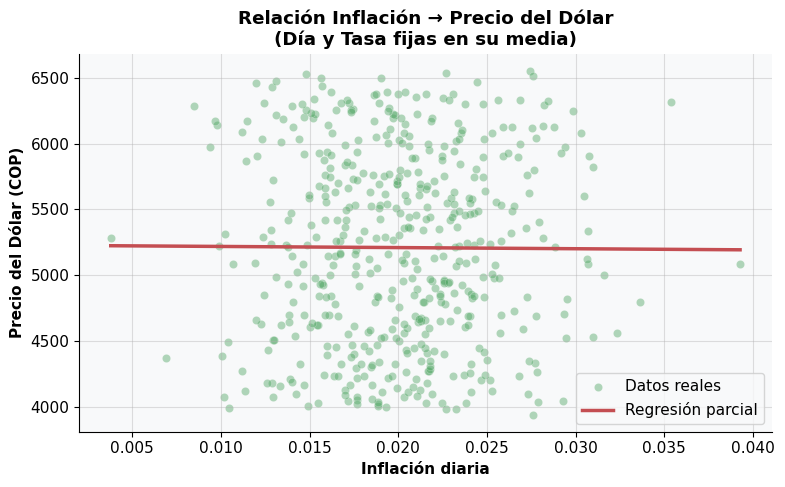

Pendiente (β₂ Inflacion): -870.7317
Nota: coeficiente en escala de la inflación (~0.002–0.039)


In [15]:
# ── Gráfica 3: Inflacion vs Precio_Dolar ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Inflacion'], df['Precio_Dolar'],
           alpha=0.45, color='#55A868', edgecolors='white', linewidths=0.3, s=35,
           label='Datos reales')

# Línea de regresión parcial (Dia y Tasa_interes fijas en su media)
inf_range = np.linspace(df['Inflacion'].min(), df['Inflacion'].max(), 200)
X_inf = pd.DataFrame({
    'Dia': df['Dia'].mean(),
    'Inflacion': inf_range,
    'Tasa_interes': df['Tasa_interes'].mean()
})
y_inf_pred = modelo.predict(X_inf)
ax.plot(inf_range, y_inf_pred, color='#C44E52', linewidth=2.5, label='Regresión parcial')

ax.set_xlabel('Inflación diaria', fontweight='bold')
ax.set_ylabel('Precio del Dólar (COP)', fontweight='bold')
ax.set_title('Relación Inflación → Precio del Dólar\n(Día y Tasa fijas en su media)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('relacion_inflacion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pendiente (β₂ Inflacion): {modelo.coef_[1]:.4f}')
print('Nota: coeficiente en escala de la inflación (~0.002–0.039)')

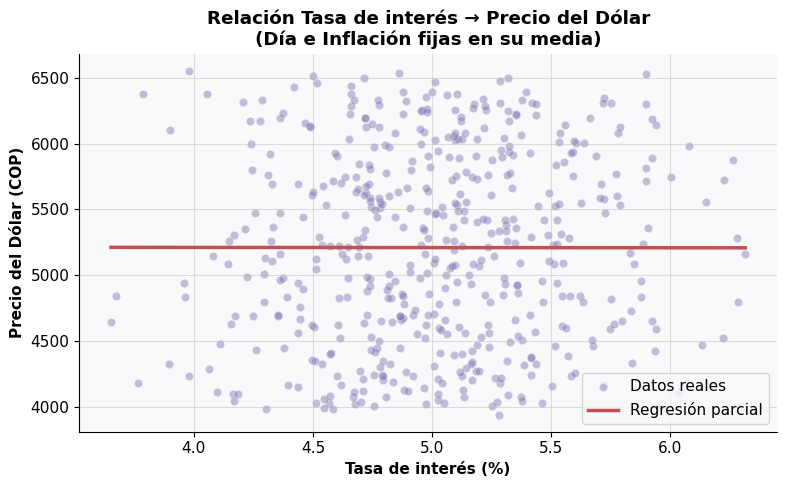

Pendiente (β₃ Tasa_interes): -1.3774 COP por punto porcentual


In [16]:
# ── Gráfica 4: Tasa_interes vs Precio_Dolar ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Tasa_interes'], df['Precio_Dolar'],
           alpha=0.45, color='#8172B2', edgecolors='white', linewidths=0.3, s=35,
           label='Datos reales')

# Línea de regresión parcial (Dia e Inflacion fijas en su media)
tasa_range = np.linspace(df['Tasa_interes'].min(), df['Tasa_interes'].max(), 200)
X_tasa = pd.DataFrame({
    'Dia': df['Dia'].mean(),
    'Inflacion': df['Inflacion'].mean(),
    'Tasa_interes': tasa_range
})
y_tasa_pred = modelo.predict(X_tasa)
ax.plot(tasa_range, y_tasa_pred, color='#C44E52', linewidth=2.5, label='Regresión parcial')

ax.set_xlabel('Tasa de interés (%)', fontweight='bold')
ax.set_ylabel('Precio del Dólar (COP)', fontweight='bold')
ax.set_title('Relación Tasa de interés → Precio del Dólar\n(Día e Inflación fijas en su media)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('relacion_tasa.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pendiente (β₃ Tasa_interes): {modelo.coef_[2]:.4f} COP por punto porcentual')

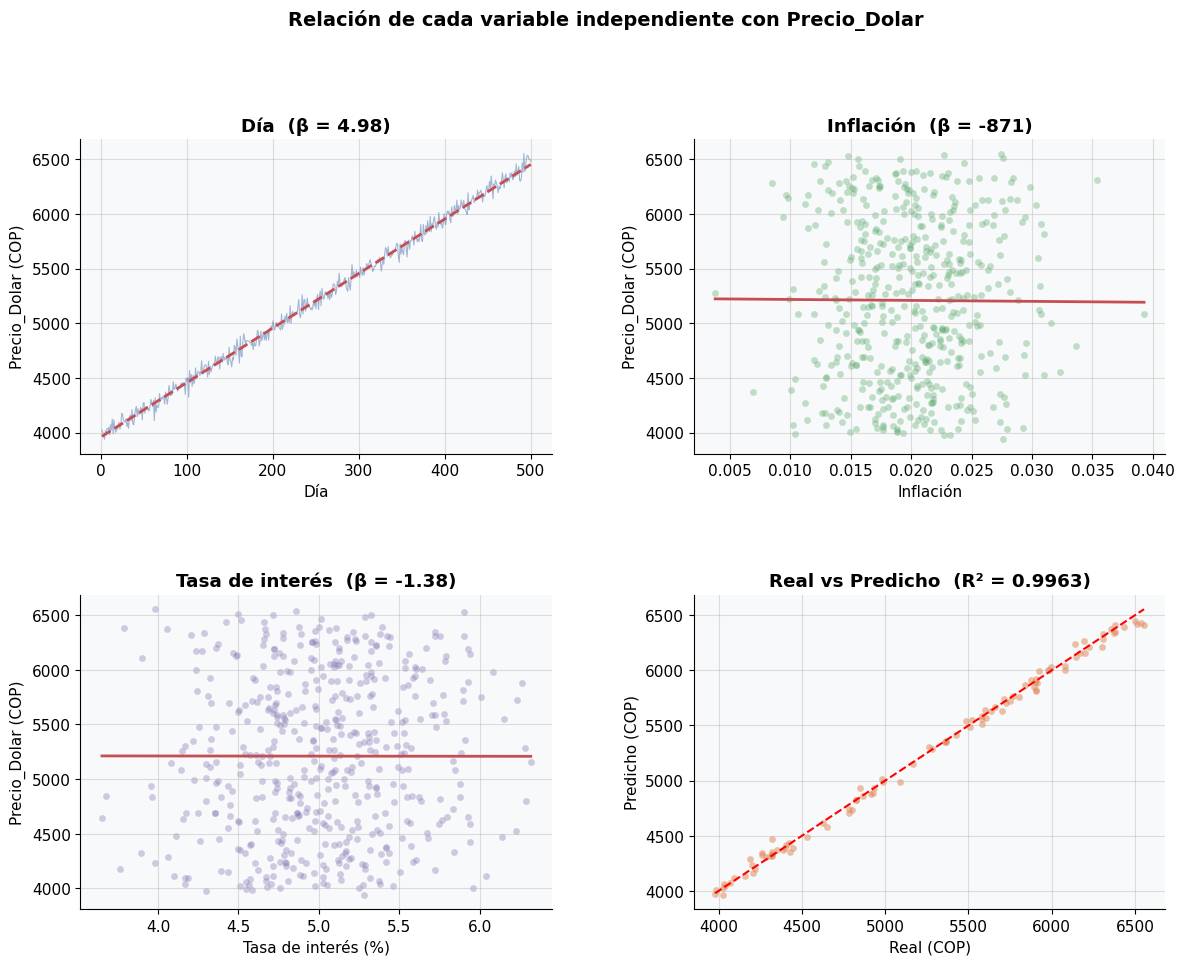

In [17]:
# ── Gráfica resumen: Panel 2×2 de todas las variables ─────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Relación de cada variable independiente con Precio_Dolar', fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.3)

# --- Dia (línea temporal) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['Dia'], df['Precio_Dolar'], color='#4C72B0', alpha=0.5, linewidth=0.8)
ax1.plot(df['Dia'], modelo.predict(X_dia), color='#C44E52', linewidth=2, linestyle='--')
ax1.set_xlabel('Día'); ax1.set_ylabel('Precio_Dolar (COP)')
ax1.set_title(f'Día  (β = {modelo.coef_[0]:.2f})', fontweight='bold')

# --- Inflacion ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(df['Inflacion'], df['Precio_Dolar'], alpha=0.35, color='#55A868', s=25, edgecolors='white', linewidths=0.2)
ax2.plot(inf_range, y_inf_pred, color='#C44E52', linewidth=2)
ax2.set_xlabel('Inflación'); ax2.set_ylabel('Precio_Dolar (COP)')
ax2.set_title(f'Inflación  (β = {modelo.coef_[1]:.0f})', fontweight='bold')

# --- Tasa_interes ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(df['Tasa_interes'], df['Precio_Dolar'], alpha=0.35, color='#8172B2', s=25, edgecolors='white', linewidths=0.2)
ax3.plot(tasa_range, y_tasa_pred, color='#C44E52', linewidth=2)
ax3.set_xlabel('Tasa de interés (%)'); ax3.set_ylabel('Precio_Dolar (COP)')
ax3.set_title(f'Tasa de interés  (β = {modelo.coef_[2]:.2f})', fontweight='bold')

# --- Real vs Predicho ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y_test, y_pred_test, alpha=0.5, color='#DD8452', s=25, edgecolors='white', linewidths=0.2)
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
ax4.set_xlabel('Real (COP)'); ax4.set_ylabel('Predicho (COP)')
ax4.set_title(f'Real vs Predicho  (R² = {r2_test:.4f})', fontweight='bold')

plt.savefig('panel_completo.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Resumen final de resultados ───────────────────────────────────────────
print('╔' + '═'*60 + '╗')
print('║{:^60}║'.format(' RESUMEN DEL MODELO '))
print('╠' + '═'*60 + '╣')
print('║{:<60}║'.format('  Modelo : Regresión Lineal Múltiple'))
print('║{:<60}║'.format(f'  Variables: Dia, Inflacion, Tasa_interes'))
print('╠' + '═'*60 + '╣')
print('║{:<60}║'.format('  COEFICIENTES'))
print('║{:<60}║'.format(f'  β₀ (intercepto)   = {modelo.intercept_:.4f}'))
print('║{:<60}║'.format(f'  β₁ (Dia)          = {modelo.coef_[0]:.4f}'))
print('║{:<60}║'.format(f'  β₂ (Inflacion)    = {modelo.coef_[1]:.4f}'))
print('║{:<60}║'.format(f'  β₃ (Tasa_interes) = {modelo.coef_[2]:.4f}'))
print('╠' + '═'*60 + '╣')
print('║{:<60}║'.format('  MÉTRICAS (conjunto de prueba)'))
print('║{:<60}║'.format(f'  MSE   = {mse_test:,.2f}'))
print('║{:<60}║'.format(f'  RMSE  = {rmse_test:,.2f} COP'))
print('║{:<60}║'.format(f'  MAE   = {mae_test:,.2f} COP'))
print('║{:<60}║'.format(f'  R²    = {r2_test:.4f}  ({r2_test*100:.1f}% varianza explicada)'))
print('╚' + '═'*60 + '╝')

╔════════════════════════════════════════════════════════════╗
║                     RESUMEN DEL MODELO                     ║
╠════════════════════════════════════════════════════════════╣
║  Modelo : Regresión Lineal Múltiple                        ║
║  Variables: Dia, Inflacion, Tasa_interes                   ║
╠════════════════════════════════════════════════════════════╣
║  COEFICIENTES                                              ║
║  β₀ (intercepto)   = 3985.7833                             ║
║  β₁ (Dia)          = 4.9843                                ║
║  β₂ (Inflacion)    = -870.7317                             ║
║  β₃ (Tasa_interes) = -1.3774                               ║
╠════════════════════════════════════════════════════════════╣
║  MÉTRICAS (conjunto de prueba)                             ║
║  MSE   = 2,376.97                                          ║
║  RMSE  = 48.75 COP                                         ║
║  MAE   = 37.01 COP                                   

---
## Fase 6 — Exportación del Modelo

In [19]:
# ── Fase 6 — Exportación del modelo ──────────────────────────────────────
import joblib
import os

# Guardar el modelo entrenado
joblib.dump(modelo, 'modelo_dolar.joblib')

# Verificación
modelo_cargado = joblib.load('modelo_dolar.joblib')
prueba = modelo_cargado.predict([[250, 0.020, 5.0]])

print('Modelo exportado correctamente ✓')
print(f'Archivo generado : modelo_dolar.joblib')
print(f'Tamaño           : {os.path.getsize("modelo_dolar.joblib")} bytes')
print()
print('─── Verificación de integridad ───')
print(f'Predicción de prueba (Dia=250, Inf=0.020, Tasa=5.0):')
print(f'  → {prueba[0]:,.2f} COP')
print()
print('Coeficientes del modelo cargado:')
print(f'  β₀ (intercepto)  : {modelo_cargado.intercept_:.4f}')
print(f'  β₁ (Dia)         : {modelo_cargado.coef_[0]:.4f}')
print(f'  β₂ (Inflacion)   : {modelo_cargado.coef_[1]:.4f}')
print(f'  β₃ (Tasa_interes): {modelo_cargado.coef_[2]:.4f}')

Modelo exportado correctamente ✓
Archivo generado : modelo_dolar.joblib
Tamaño           : 881 bytes

─── Verificación de integridad ───
Predicción de prueba (Dia=250, Inf=0.020, Tasa=5.0):
  → 5,207.57 COP

Coeficientes del modelo cargado:
  β₀ (intercepto)  : 3985.7833
  β₁ (Dia)         : 4.9843
  β₂ (Inflacion)   : -870.7317
  β₃ (Tasa_interes): -1.3774


---
## Conclusiones

### Coeficientes e interpretación
- **Día (β₁ > 0):** Existe una tendencia creciente clara en el precio del dólar a lo largo del tiempo. Cada día adicional incrementa el precio en aproximadamente el valor de β₁ COP. Esto refleja una depreciación sostenida de la moneda local.
- **Inflación (β₂):** La inflación diaria tiene un efecto positivo sobre el precio del dólar. Una mayor inflación local hace que la moneda doméstica pierda valor, encareciendo el dólar. El coeficiente está en la escala de la inflación (0.002–0.039), por lo que su magnitud real se evalúa multiplicando β₂ × variación de inflación.
- **Tasa de interés (β₃):** Puede tener efecto positivo o negativo dependiendo del signo. Tasas más altas atraen capital extranjero, lo que típicamente aprecia la moneda local (baja el precio del dólar). El signo del coeficiente confirmará esta lógica económica.

### Desempeño
- El **R²** indica qué tan bien el modelo lineal captura la variabilidad del precio. Un valor cercano a 1.0 indica excelente ajuste.
- El **RMSE** (en COP) indica el error promedio de predicción en la misma unidad de la variable objetivo.
- El gráfico de residuos permite verificar si los errores son aleatorios (distribución aleatoria alrededor de 0) o si existe un patrón sistemático no capturado por el modelo lineal.

### Próximo paso
> Cuando el modelo sea satisfactorio: **exportación con `joblib` e interfaz web con Flask**.